<a href="https://colab.research.google.com/github/GaelCETI/Proyecto-Visi-n-Artificial-/blob/main/ProyectoVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sat Jun 20 05:03:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!unzip -q /content/data.zip -d /content/custom_data

In [7]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

# TO DO: Improve robustness of train_val_split.py script so it can handle nested data folders, etc
!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.9


--2026-06-20 05:15:51--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-06-20 05:15:51 (56.1 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Number of image files: 144
Number of annotation files: 144
Images moving to train: 129
Images moving to validation: 15


In [4]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00


In [5]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 6
names:
- amortiguador
- bloque motor
- "cigue\xF1al"
- frenos
- luces
- piston


In [8]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=60 imgsz=640

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

In [12]:
!yolo detect predict model=runs/detect/train-2/weights/best.pt source=data/validation/images save=True

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs

image 1/14 /content/data/validation/images/191dc952-019.jpg: 640x640 3 bloque motors, 15.6ms
image 2/14 /content/data/validation/images/2008 Aston Martin DBS V-12.jpg: 640x448 3 frenoss, 52.6ms
image 3/14 /content/data/validation/images/263K views · 3K reactions _ Follow us for more 👇😍 _ reelsviralシ fyp trending reelsvideo reelsfb trendingreels _ Engineering Club _ Facebook.jpg: 640x384 1 amortiguador, 1 frenos, 53.5ms
image 4/14 /content/data/validation/images/4dcab0d1-022.jpg: 640x640 2 bloque motors, 16.2ms
image 5/14 /content/data/validation/images/6cde8458-096.jpg: 640x640 1 amortiguador, 1 luces, 15.5ms
image 6/14 /content/data/validation/images/8801ecd4e980bd7bf834aa70f384ae4f.jpg: 640x480 1 frenos, 52.5ms
image 7/14 /content/data/validation/images/Anatomia do Motor.jpg: 640x416 1 frenos, 53.1ms
image 8/14 /conten

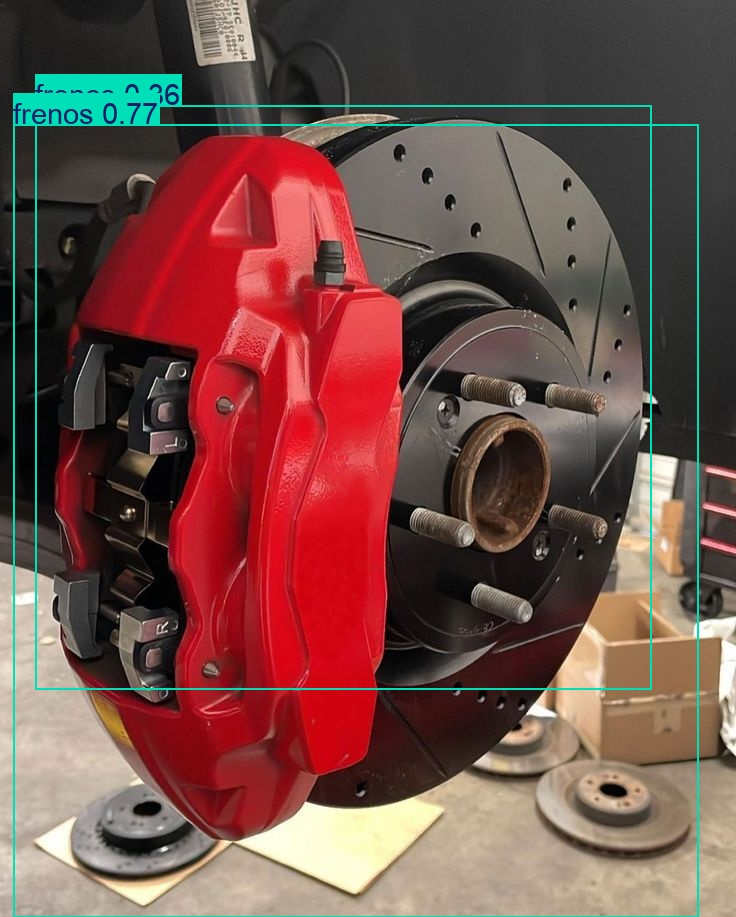


Displayed image: Performance Brake Rotors.jpg
Saved image to: /content/runs/detect/evidencias/Performance Brake Rotors.jpg


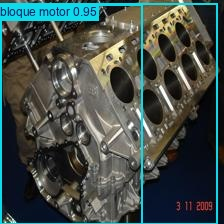


Displayed image: 4dcab0d1-022.jpg
Saved image to: /content/runs/detect/evidencias/4dcab0d1-022.jpg


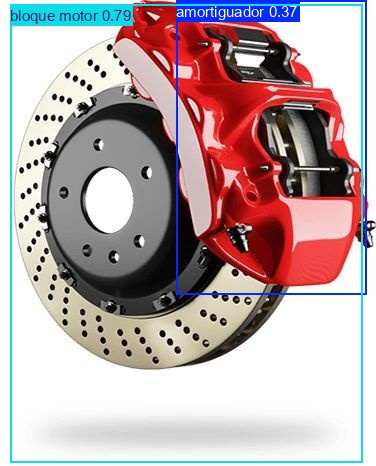


Displayed image: WELCOME TO ROHNERT PARK TRANSMISSION AND AUTO REPAIR.jpg
Saved image to: /content/runs/detect/evidencias/WELCOME TO ROHNERT PARK TRANSMISSION AND AUTO REPAIR.jpg


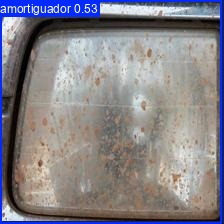


Displayed image: 6cde8458-096.jpg
Saved image to: /content/runs/detect/evidencias/6cde8458-096.jpg


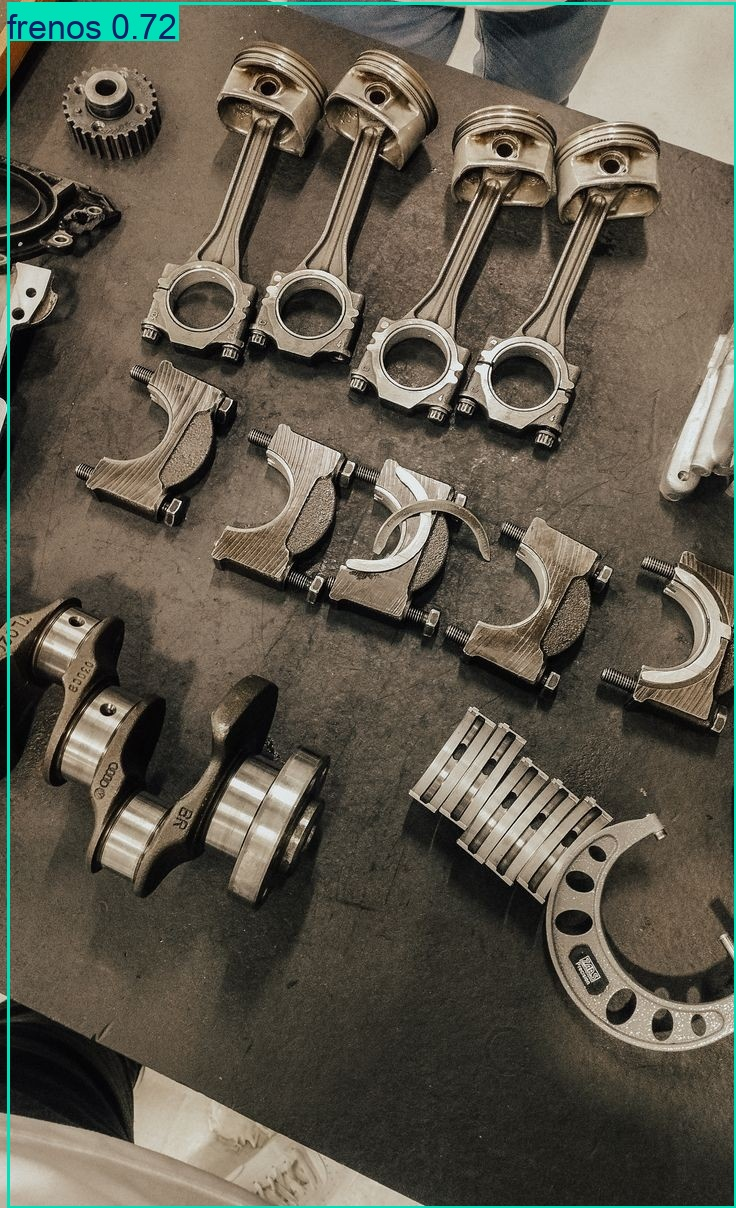


Displayed image: Anatomia do Motor.jpg
Saved image to: /content/runs/detect/evidencias/Anatomia do Motor.jpg


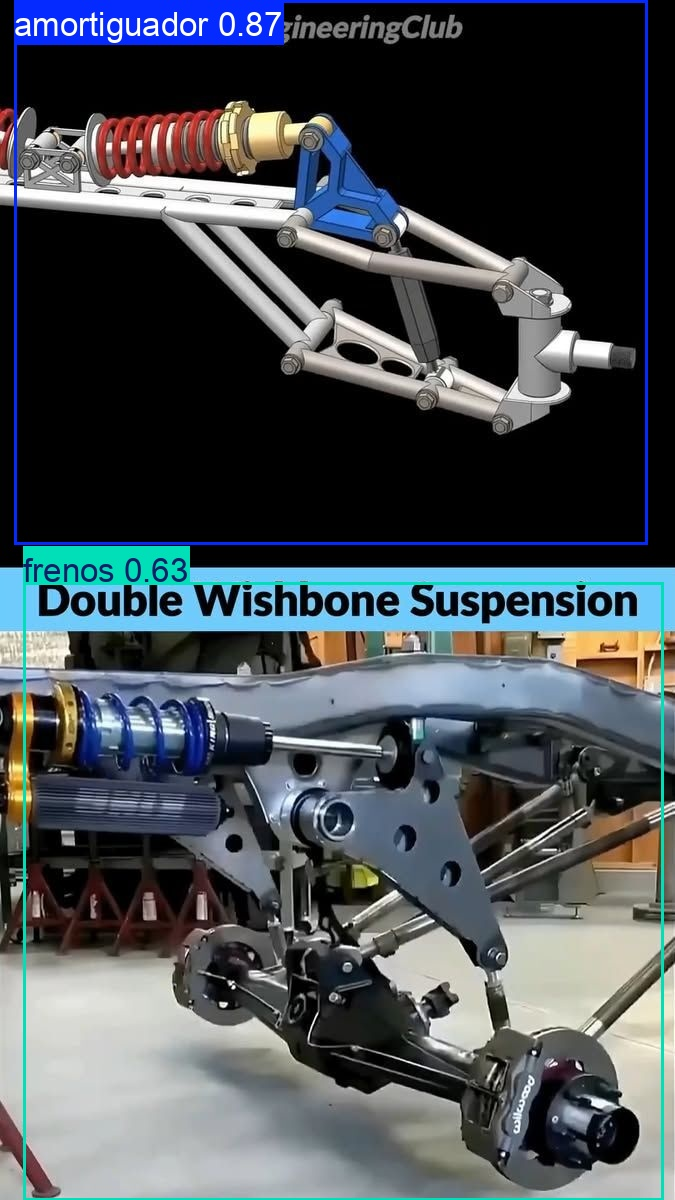


Displayed image: 263K views · 3K reactions _ Follow us for more 👇😍 _ reelsviralシ fyp trending reelsvideo reelsfb trendingreels _ Engineering Club _ Facebook.jpg
Saved image to: /content/runs/detect/evidencias/263K views · 3K reactions _ Follow us for more 👇😍 _ reelsviralシ fyp trending reelsvideo reelsfb trendingreels _ Engineering Club _ Facebook.jpg


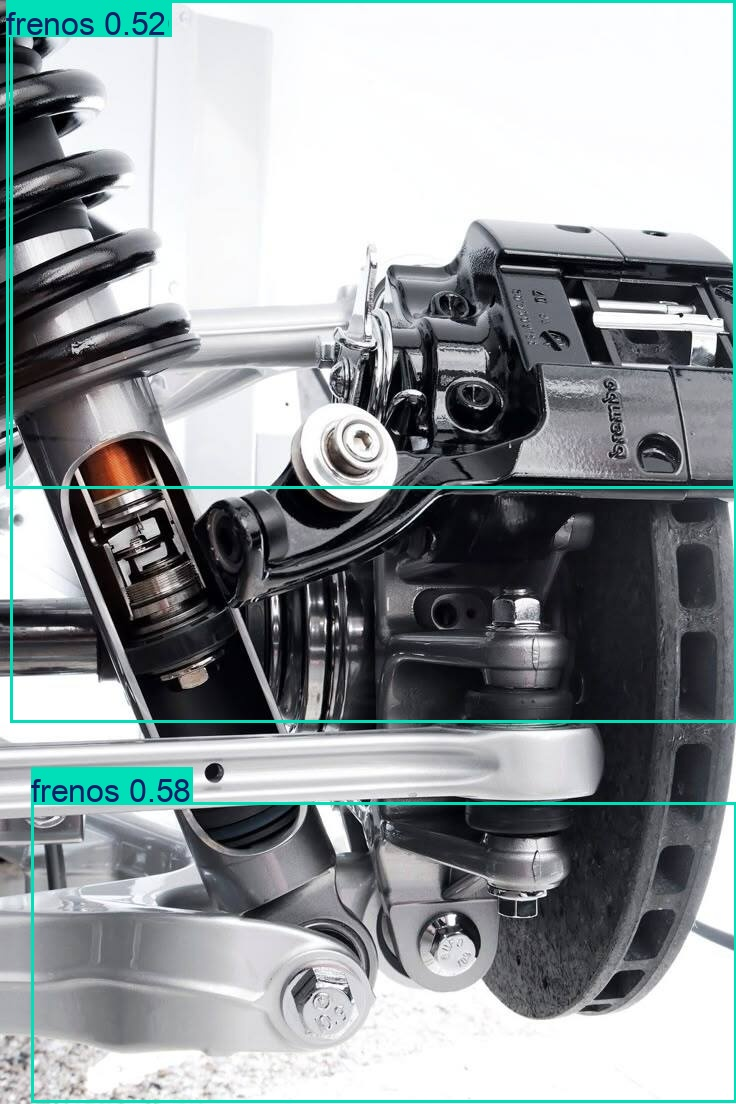


Displayed image: 2008 Aston Martin DBS V-12.jpg
Saved image to: /content/runs/detect/evidencias/2008 Aston Martin DBS V-12.jpg


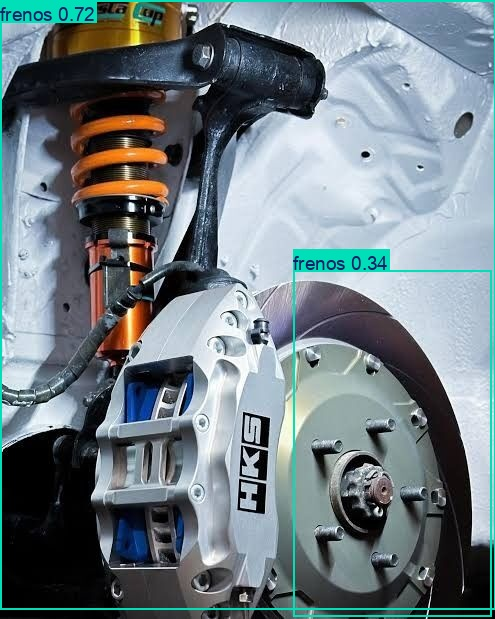


Displayed image: descargar (4).jpg
Saved image to: /content/runs/detect/evidencias/descargar (4).jpg


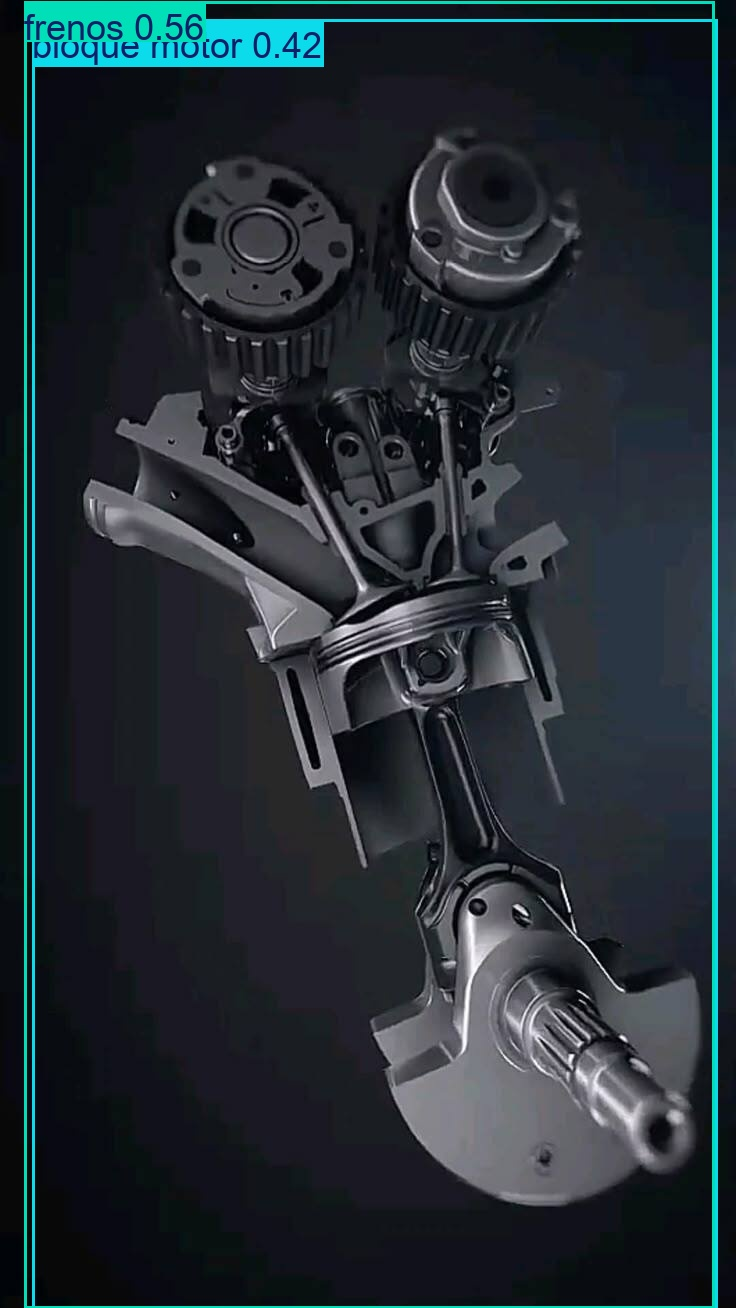


Displayed image: descargar (1).jpg
Saved image to: /content/runs/detect/evidencias/descargar (1).jpg


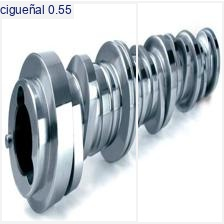


Displayed image: ae5cd731-029.jpg
Saved image to: /content/runs/detect/evidencias/ae5cd731-029.jpg


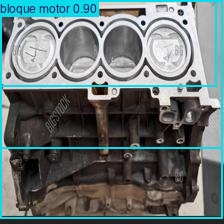


Displayed image: 191dc952-019.jpg
Saved image to: /content/runs/detect/evidencias/191dc952-019.jpg


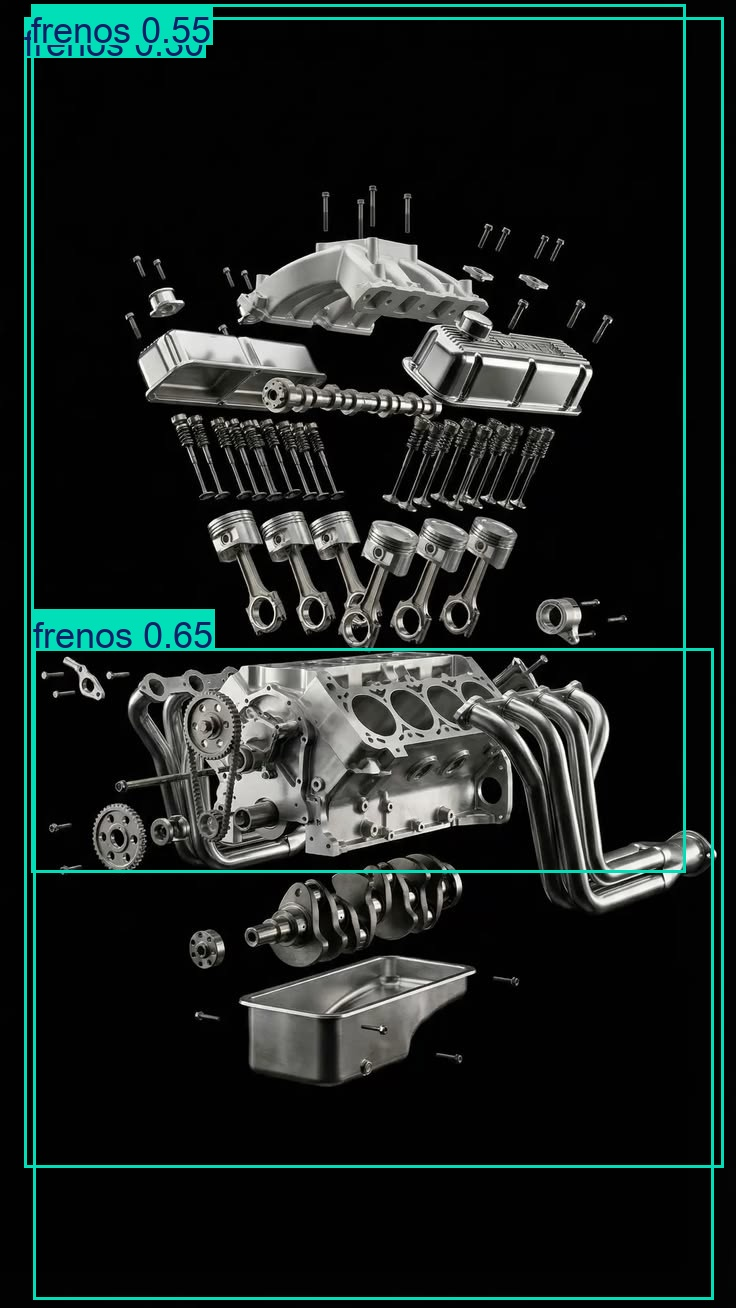


Displayed image: Pure art_ Engines are just artistic pieces.jpg
Saved image to: /content/runs/detect/evidencias/Pure art_ Engines are just artistic pieces.jpg


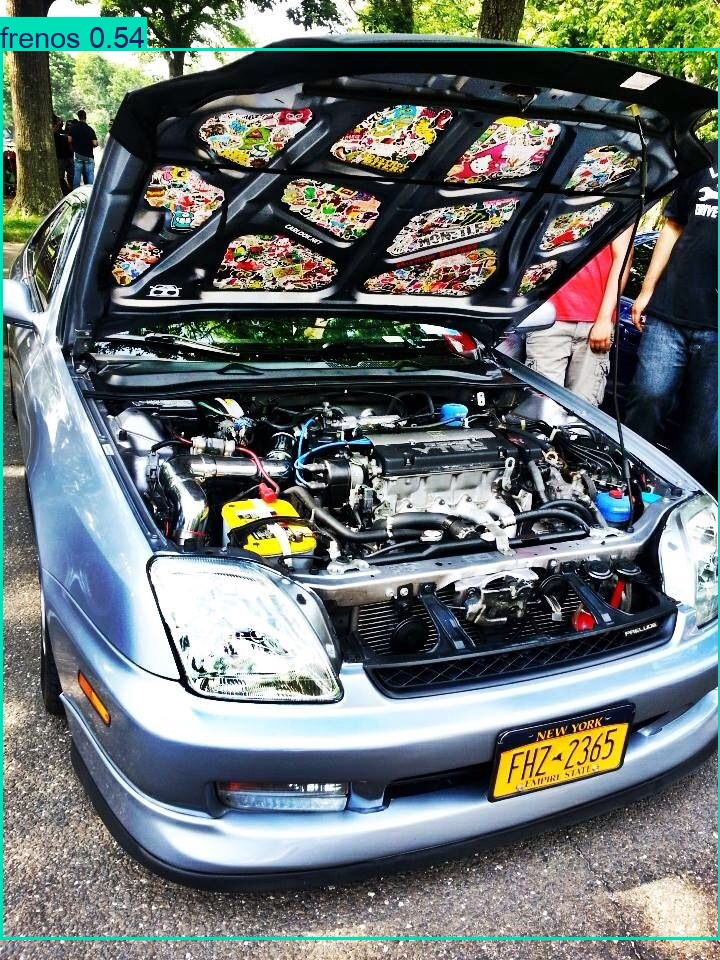


Displayed image: 8801ecd4e980bd7bf834aa70f384ae4f.jpg
Saved image to: /content/runs/detect/evidencias/8801ecd4e980bd7bf834aa70f384ae4f.jpg


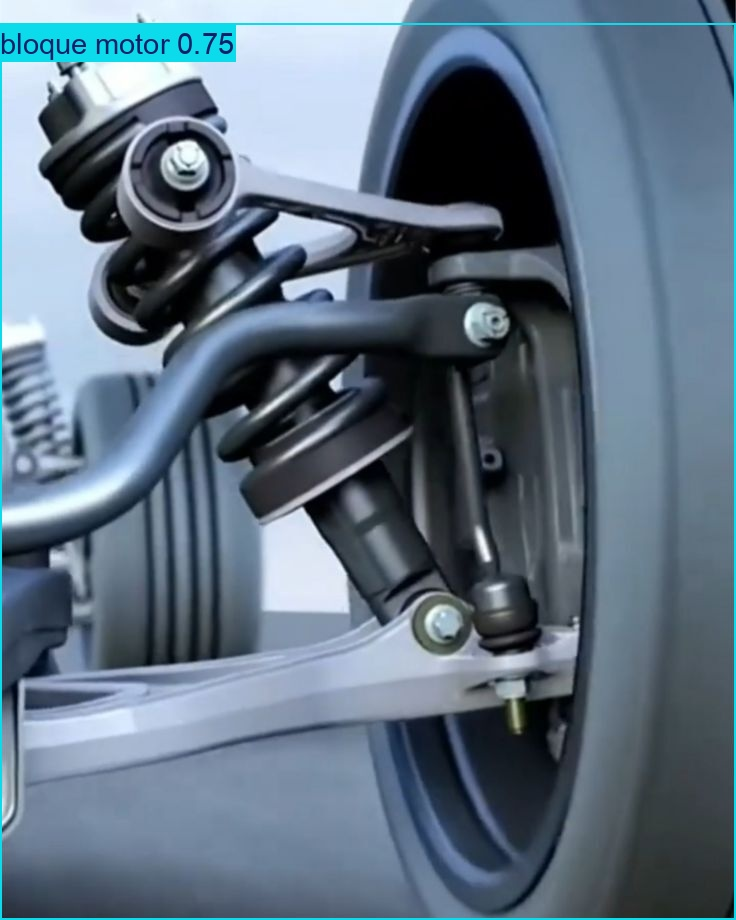


Displayed image: descargar.jpg
Saved image to: /content/runs/detect/evidencias/descargar.jpg


In [17]:
import glob
import os
import shutil
from IPython.display import Image, display

output_dir = '/content/runs/detect/evidencias'
os.makedirs(output_dir, exist_ok=True)

for i, image_path in enumerate(glob.glob(f'/content/runs/detect/predict/*.jpg')[:15]):
  display(Image(filename=image_path, height=400))
  print(f'\nDisplayed image: {os.path.basename(image_path)}')

  # Save image to the new directory
  destination_path = os.path.join(output_dir, os.path.basename(image_path))
  shutil.copy(image_path, destination_path)
  print(f'Saved image to: {destination_path}')


In [18]:

from google.colab import files

# Descargamos el mejor modelo entrenado a tu computadora
files.download('runs/detect/train-2/weights/best.pt')

print("Modelo descargado exitosamente.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modelo descargado exitosamente.


In [19]:
import shutil

# Comprimimos las imágenes de evidencia en un ZIP
shutil.make_archive('evidencias', 'zip', 'runs/detect/evidencias')

# Descargamos el ZIP
files.download('evidencias.zip')

print("Evidencias descargadas.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Evidencias descargadas.
